## 7. Collision impulse — PushT physics의 핵심

### 7.1 Contact point의 속도

질량중심 속도가 $\mathbf v_G$ 라도 contact point의 속도는 다릅니다. Meriam에서 본 relative velocity:

$$
\boxed{\mathbf v_C=\mathbf v_G+\boldsymbol\omega\times\mathbf r},
\qquad \mathbf r = \mathbf x_{\text{contact}}-\mathbf x_G
$$

```text
       contact
          ●
         /
        / r
       /
      G
```

### 7.2 상대속도와 normal 성분

Pusher 속도가 $\mathbf v_P$ 이면

$$
\boxed{\mathbf v_{\text{rel}}=\mathbf v_C-\mathbf v_P},\qquad
\boxed{v_n=\mathbf v_{\text{rel}}\cdot\mathbf n}
$$

normal을 pusher → T 방향으로 정의했으므로 $v_n<0$ 이면 두 물체가 **서로 접근**하고 있다는 뜻입니다.

### 7.3 Collision 조건 (restitution)

충돌 뒤에는 서로 계속 파고들면 안 됩니다. Coefficient of restitution $e$ 를 쓰면

$$
\boxed{v_n^{+}=-e\,v_n^{-}}
$$

PushT처럼 거의 비탄성 충돌이면 $e\approx0$ 이고, 충돌 뒤 $v_n^{+}\approx0$ — normal 방향으로 더 이상 파고들지 않습니다.

### 7.4 Impulse가 속도를 바꾸는 방식

Normal impulse를 $\mathbf J = j\,\mathbf n$ 이라 하면, **linear impulse–momentum**:

$$
m\mathbf v^{+}=m\mathbf v^{-}+\mathbf J
\quad\Rightarrow\quad
\boxed{\Delta\mathbf v_G=\frac{\mathbf J}{m}}
$$

Impulse가 COM을 지나지 않으면 **angular impulse** 가 생깁니다. 2D에서 $L=I\omega$ 이므로

$$
I\,\Delta\omega=\mathbf r\times\mathbf J
\quad\Rightarrow\quad
\boxed{\Delta\omega=\frac{\mathbf r\times\mathbf J}{I}}
$$

이 한 줄이 바로 "pusher가 T의 옆부분을 밀면 T가 회전하는 이유" 입니다.

### 7.5 Scalar $j$ 계산 — effective inverse mass

Impulse를 가하면 $\mathbf v_G$ 뿐만 아니라 $\omega$ 도 변합니다. 둘을 모두 고려하면 contact normal 방향의 effective inverse mass는

$$
\boxed{K_n=\frac1m+\frac{(\mathbf r\times\mathbf n)^2}{I}}
$$

이고, $v_n^{+}=-e\,v_n^{-}$ 을 만족하는 impulse 크기는

$$
\boxed{j=-\frac{(1+e)\,v_n}{K_n}}
$$

**왜 분모에 회전항이 들어가는가?** contact가 COM 근처면 $\mathbf r\times\mathbf n\approx0$, $K_n\approx 1/m$ 이고 대부분 translation이 됩니다.
멀리 떨어진 곳을 밀면 $\lvert\mathbf r\times\mathbf n\rvert$ 가 커져서 impulse의 일부가 회전으로 들어갑니다.

$$
\boxed{\text{same push}+\text{different contact position}\Rightarrow\text{different translation / rotation}}
$$

이것이 PushT task의 본질 중 하나입니다 (아래 실험 8에서 직접 확인).

### 7.6 Pusher도 dynamic body라면?

일반적으로 두 rigid body A, B가 충돌하면

$$
K_n=\frac1{m_A}+\frac1{m_B}+\frac{(\mathbf r_A\times\mathbf n)^2}{I_A}+\frac{(\mathbf r_B\times\mathbf n)^2}{I_B}
$$

하지만 kinematic pusher는 $1/m_P = 0$, $1/I_P=0$ 처럼 취급하므로 T의 항만 남습니다.

### 7.7 Friction impulse $j_t$

Normal impulse만 쓰면 pusher가 T 표면에서 너무 쉽게 미끄러집니다. tangent를

$$
\mathbf n=(n_x,n_y)\ \Rightarrow\ \boxed{\mathbf t=(-n_y,\ n_x)}
$$

로 정의하고, 상대속도의 tangent 성분 $v_t=\mathbf v_{\text{rel}}\cdot\mathbf t$ 을 없애는 impulse는

$$
j_t^{*}=-\frac{v_t}{K_t},\qquad K_t=\frac1m+\frac{(\mathbf r\times\mathbf t)^2}{I}
$$

그러나 **Coulomb friction** 때문에 무한히 큰 마찰은 쓸 수 없으므로 clamp 합니다.

$$
\boxed{\lvert j_t\rvert\le\mu\,j_n}
$$

### 7.8 Position correction

이론적인 충돌 순간에는 penetration $=0$ 이어야 하지만, discrete simulation은 $t\rightarrow t+\Delta t$ 로 점프하기 때문에 이미 겹친 상태가 생깁니다.

```text
previous          next

○   | T            ○|T
                     ↑
                   already overlapping
```

velocity impulse만으로는 이미 생긴 겹침이 남으므로, normal 방향으로 직접 조금 밀어냅니다 (**penetration correction**).

$$
\Delta\mathbf x_G=\beta\,\max(\delta-\text{slop},\,0)\,\mathbf n
$$

## 8. 실험: 같은 push, 다른 contact 높이

7.5의 주장을 숫자로 확인합니다. 정지한 T의 **stem 왼쪽 면** ($x=-0.25$) 을 pusher가 같은 속도 $\mathbf v_P=(1,0)$ 로 밀고,
접촉 높이 $y$ 만 바꿉니다. 마찰은 끄고 ($\mu=0$), $e=0$ 입니다.

이때 $\mathbf n=(1,0)$, $\mathbf r=(-0.25,\,y)$ 이므로 $\mathbf r\times\mathbf n=-y$ 이고

$$
K_n=\frac1m+\frac{y^2}{I},\qquad j=\frac{1}{K_n},\qquad
\Delta v_x=\frac{j}{m},\qquad \Delta\omega=\frac{-y\,j}{I}
$$

- $y=0$ (COM 높이) : 회전 없이 순수 translation, $\Delta v_x = 1$
- $\lvert y\rvert$ 가 클수록 : $j$ 와 $\Delta v_x$ 는 줄고, 그만큼 $\lvert\Delta\omega\rvert$ 가 커짐

In [10]:
stem_left = -0.25
y_bottom = vertices[:, 1].min()             # bottom of the stem (COM frame)
y_stem_top = vertices[3, 1]                 # where the stem meets the top bar

print(f"{'contact y':>10s} {'K_n':>8s} {'j_n':>8s} {'dv_x':>8s} {'d_omega':>9s}")
for y in np.sort(np.r_[np.linspace(y_bottom + 0.05, y_stem_top - 0.05, 5), 0.0]):   # include y = 0 (COM height)
    body = TBody(pos=np.zeros(2), angle=0.0, vel=np.zeros(2), omega=0.0,
                 mass=1.0, inertia=inertia, vertices=vertices)
    pusher = Pusher(pos=np.array([stem_left - 0.18, y]), vel=np.array([1.0, 0.0]), radius=0.18)
    contact = (np.array([stem_left, y]), np.array([1.0, 0.0]), 0.0)   # point, normal, penetration
    K_n = 1.0 / body.mass + cross2(contact[0] - body.pos, contact[1]) ** 2 / body.inertia
    jn, _ = resolve_impulse(body, pusher, contact, restitution=0.0, friction=0.0)
    print(f"{y:10.3f} {K_n:8.3f} {jn:8.3f} {body.vel[0]:8.3f} {body.omega:9.3f}")

 contact y      K_n      j_n     dv_x   d_omega
    -1.123    3.904    0.256    0.256     0.663
    -0.823    2.559    0.391    0.391     0.741
    -0.523    1.629    0.614    0.614     0.739
    -0.223    1.114    0.898    0.898     0.460
     0.000    1.000    1.000    1.000     0.000
     0.077    1.014    0.986    0.986    -0.176


## 9. Mini PushT simulator

한 번의 `step(action)` 이 하는 일 (substep마다 반복):

**A. Pusher PD control**

$$
\mathbf a_P = K_p\,(\mathbf x^{*}-\mathbf x_P) - K_d\,\mathbf v_P,\qquad
\mathbf v_P \leftarrow \mathbf v_P+\mathbf a_P\Delta t,\qquad
\mathbf x_P \leftarrow \mathbf x_P+\mathbf v_P\Delta t
$$

(속도는 `max_speed` 로 제한)

**B. T damping** — 바닥 마찰을 흉내 낸 지수 감쇠

$$
\mathbf v_G \leftarrow \mathbf v_G\,e^{-c_v\Delta t},\qquad
\omega \leftarrow \omega\,e^{-c_\omega\Delta t}
$$

**C. T 적분** (semi-implicit Euler)

$$
\mathbf x_G \leftarrow \mathbf x_G+\mathbf v_G\Delta t,\qquad
\theta \leftarrow \theta+\omega\Delta t
$$

**D. Contact solver** — `circle_vs_T` → `resolve_impulse` 를 최대 3번 반복

왜 여러 번 돌리나? 한 번의 impulse로 충돌이 완벽하게 해결되지 않는 경우가 많기 때문입니다
(friction, rotation, penetration, 여러 contact, corner contact).
Pymunk, Box2D 같은 physics engine도 훨씬 정교한 **iterative constraint solver** 를 사용합니다.

## 10. Test: one control step

Pusher는 T의 왼쪽 ($x=-1.15$, $y=0.30$) 에서 시작하고, target을 오른쪽 ($x=0$) 으로 줍니다.
$y=0.30$ 은 COM보다 위이므로, push와 함께 회전도 생겨야 합니다.

In [12]:
# ============================================================
# 8. Test one step
# ============================================================

sim = MiniPushT()


print(
    "Before:"
)

print(
    "obs =",
    sim.observation()
)

print(
    "T velocity =",
    sim.T.vel
)

print(
    "T omega =",
    sim.T.omega
)


# pusher target:
# move to the right

action = np.array([
    0.0,
    0.30
])


obs, impulses = sim.step(
    action
)


print("\nAfter one step:")

print(
    "obs =",
    obs
)

print(
    "T velocity =",
    sim.T.vel
)

print(
    "T omega =",
    sim.T.omega
)

print(
    "impulses =",
    impulses
)

Before:
obs = [-1.15  0.3   0.    0.    0.  ]
T velocity = [0. 0.]
T omega = 0.0

After one step:
obs = [-0.89407163  0.3         0.17344028 -0.0353482  -0.03941292]
T velocity = [ 2.77680868 -0.60348411]
T omega = -0.6797886601763609
impulses = [(2.268900940788392, -0.4924864426901922), (0.2538111572163098, -0.055092116048877385), (0.028392647016797282, -0.006162893001000409), (0.2507357736399877, -0.05320528616215671), (0.027356132582000495, -0.005916805058162459), (0.003042195903985738, -0.0006579906738888818), (0.03475679434675382, -0.006831078735145252), (0.0035030893759654797, -0.0007546723168218663), (0.00038700835957082206, -8.337340672788465e-05), (0.03450178978117609, -0.006644716941218448), (0.0033985507842055596, -0.0007292415218624775), (0.0003729826820198361, -8.003248323624901e-05), (0.034534009783508055, -0.006519228768877586), (0.003325540173116646, -0.0007107322923347686), (0.0003625534360396655, -7.748468557780077e-05), (0.03456357225059276, -0.006392851538712673), (

## 11. 실험: 여러 step rollout과 시각화

같은 target을 15 step (1.5 s) 동안 유지하면서 T와 pusher를 그립니다.
색이 진해질수록 나중 시점입니다. T가 오른쪽으로 밀리면서 동시에 회전하는 것이 보여야 합니다.

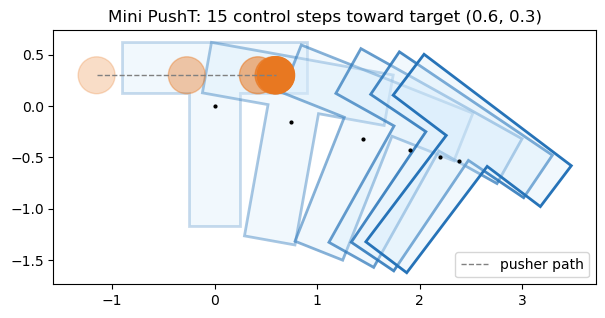

final T position: [ 2.381 -0.539]  angle (deg): -37.1


In [13]:
import matplotlib.pyplot as plt

sim = MiniPushT()
frames = [(sim.T.pos.copy(), sim.T.angle, sim.pusher.pos.copy())]
for _ in range(15):
    sim.step(np.array([0.6, 0.30]))
    frames.append((sim.T.pos.copy(), sim.T.angle, sim.pusher.pos.copy()))

fig, ax = plt.subplots(figsize=(7, 5))
for k, (pos, ang, ppos) in enumerate(frames):
    if k % 3:
        continue
    shade = 0.25 + 0.75 * k / (len(frames) - 1)
    world = pos + vertices @ rotation_matrix(ang).T
    ax.fill(*np.vstack([world, world[:1]]).T, fc=(0.85, 0.93, 0.99, 0.35), ec=(0.15, 0.45, 0.72, shade), lw=2)
    ax.add_patch(plt.Circle(ppos, sim.pusher.radius, color=(0.91, 0.47, 0.13, shade)))
    ax.plot(*pos, "k.", ms=4)
path = np.array([f[2] for f in frames])
ax.plot(path[:, 0], path[:, 1], "--", color="0.5", lw=1, label="pusher path")
ax.set_aspect("equal")
ax.set_title("Mini PushT: 15 control steps toward target (0.6, 0.3)")
ax.legend(loc="lower right")
plt.show()

print("final T position:", sim.T.pos.round(3), " angle (deg):", round(math.degrees(sim.T.angle), 1))

## 12. 정리 — PushT 1 step을 수식으로

| 단계 | 식 |
|---|---|
| Action | $a_t=(x^{*},y^{*})$ |
| Pusher controller | $\mathbf a_P=K_p(\mathbf x^{*}-\mathbf x_P)-K_d\mathbf v_P$ |
| Collision detection | $(\text{circle},\,T)\rightarrow(\mathbf q,\,\mathbf n,\,\delta)$ |
| Contact velocity | $\mathbf v_C=\mathbf v_G+\boldsymbol\omega\times\mathbf r$ |
| Normal velocity | $v_n=(\mathbf v_C-\mathbf v_P)\cdot\mathbf n$ |
| Impulse | $j_n=-(1+e)\,v_n\,/\,K_n$ |
| Velocity update | $\mathbf v_G\mathrel{+}=j_n\mathbf n/m,\quad \omega\mathrel{+}=(\mathbf r\times j_n\mathbf n)/I$ |
| Integration | $\mathbf x_G\mathrel{+}=\mathbf v_G\Delta t,\quad \theta\mathrel{+}=\omega\Delta t$ |

### 가장 중요한 4개의 식

$$
\boxed{\mathbf v_C=\mathbf v_G+\boldsymbol\omega\times\mathbf r}
$$

$$
\boxed{j=-\frac{(1+e)\,v_n}{1/m+(\mathbf r\times\mathbf n)^2/I}}
$$

$$
\boxed{\mathbf v_G^{+}=\mathbf v_G^{-}+\frac{\mathbf J}{m}}
$$

$$
\boxed{\omega^{+}=\omega^{-}+\frac{\mathbf r\times\mathbf J}{I}}
$$

이 네 식이 collision detection에서 구한 `(contact point, normal)` 을 실제 T-block의 translation과 rotation으로 연결하는 다리입니다.

이 예제는 의도적으로 단순화했습니다. Pymunk / Box2D 수준으로 가면 multiple contact manifold, warm starting,
static/dynamic friction, constraint stabilization, continuous collision detection 등이 추가됩니다.
하지만 PushT의 물리를 이해하고 작은 simulator를 직접 만드는 단계에서는 이 정도가 가장 좋은 출발점입니다.